In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable


import scipy
import numpy as np
import pandas as pd

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal
import scipy.special as special

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

import bout_clustering as clstr

In [3]:
def collect_channels(filepath, samplingrate, offset, duration_in_secs):
    channels = [[], [], [], [], [], [], [], []]

    with open(filepath, "rb") as rawFile:

        rawFile.seek(int(2*8*samplingrate*offset), 0)
        for i in range(samplingrate*duration_in_secs):
            for j in range(8):
                bytes = rawFile.read(2)
                sample_int = int.from_bytes(bytes = bytes, byteorder = "little", signed = True)
                sample_float = sample_int * (5 / 32768)

                channels[j].append(sample_float)

    return np.array(channels)

In [4]:
def plot_audio_seg_spec(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

def plot_audio_seg_signal(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Signal of {audio_features['plot_title']}", fontsize=24)
    plt.plot(audio_seg)
    plot_xtype = 'float'
    plt.xlim(0, duration*fs)
    plt.ylim(-3, 3)
    plt.grid(which='both')
    plt.xticks(ticks=np.linspace(0, audio_features['duration']*fs, 11), 
                labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_seg_fft(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"FFT of {audio_features['plot_title']}", fontsize=24)
    abs_sig = np.abs(scipy.fft.rfft(audio_seg, n=len(audio_seg)))
    abs_sig = abs_sig / len(abs_sig)
    plt.plot(20*np.log10(abs_sig/np.max(abs_sig)))
    plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, len(abs_sig), 11), 
                labels=np.round(np.linspace(0, (fs/2), 11, dtype=plot_xtype), 2)/1e3, rotation=30)
    plt.ylabel("Voltage (dB)")
    plt.xlabel("Frequency (kHz)")
    plt.grid(which='both')
    plt.show()
    
FREQ_COLORS = {'LF':'cyan',
               'HF':'orange'}

def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        plt.text(x=(row['start_time'] - start)*(fs/2), y=row['low_freq']/(fs/2), s=f"{round(row['SNR'], 2)}dB"
                 , color='w', fontsize=8, fontweight='bold')
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

In [5]:
LABEL_FOR_GROUPS = {
                    0: 'LF', 
                    1: 'HF'
                    }

def get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal): 

    signal_power_rms = np.sqrt(np.square(snr_call_signal).mean())
    noise_power_rms = np.sqrt(np.square(snr_noise_signal).mean())
    snr = abs(20 * np.log10(signal_power_rms / noise_power_rms))

    return snr

def bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    high_cutoff =  (high_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, [low_cutoff, high_cutoff], btype='band', analog=False)
    band_limited_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return band_limited_audio_seg

def highpass_audio_signal(audio_seg, fs, low_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, low_cutoff, btype='high', analog=False)
    high_passed_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return high_passed_audio_seg

def compute_welch_psd_of_call(call, fs, audio_info):
    freqs, welch = scipy.signal.welch(call, fs=fs, detrend=False, scaling='spectrum')
    cropped_welch = welch[(freqs<=audio_info['max_freq_visible'])]
    audio_spectrum_mag = np.abs(cropped_welch)
    audio_spectrum_db =  10*np.log10(audio_spectrum_mag)
    normalized_audio_spectrum_db = audio_spectrum_db - audio_spectrum_db.max()

    thresh = -100
    peak_db = np.zeros(len(normalized_audio_spectrum_db))+thresh
    peak_db[normalized_audio_spectrum_db>=thresh] = normalized_audio_spectrum_db[normalized_audio_spectrum_db>=thresh]

    original_freq_vector = np.arange(0, len(peak_db), 1).astype('int')
    common_freq_vector = np.linspace(0, len(peak_db)-1, audio_info['num_points']).astype('int')
    interp_kind = 'linear'
    interpolated_points_from_welch = scipy.interpolate.interp1d(original_freq_vector, peak_db, kind=interp_kind)(common_freq_vector)

    return interpolated_points_from_welch

def gather_features_of_interest(dets, kmean_welch, audio_file):
    fs = audio_file.samplerate
    features_of_interest = dict()
    features_of_interest['call_signals'] = []
    features_of_interest['welch_signals'] = []
    features_of_interest['snrs'] = []
    features_of_interest['peak_freqs'] = []
    features_of_interest['classes'] = []
    nyquist = fs//2
    for index, row in dets.iterrows():
        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)
        
        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]
        features_of_interest['call_signals'].append(snr_call_signal)

        high_passed_audio_seg = highpass_audio_signal(audio_seg, fs, 20000)
        snr_mod_signal = high_passed_audio_seg.copy()
        snr_mod_signal[:int(fs*(length_of_section))] = 0
        snr_mod_noise = high_passed_audio_seg - snr_mod_signal
        snr_mod_call_signal = snr_mod_signal[-int(fs*length_of_section):]
        snr_mod_noise_signal = snr_mod_noise[:int(fs*length_of_section)]
        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_mod_call_signal, snr_mod_noise_signal)
        features_of_interest['snrs'].append(snr)

        welch_info = dict()
        welch_info['num_points'] = 100
        max_visible_frequency = 96000
        welch_info['max_freq_visible'] = max_visible_frequency
        welch_signal = compute_welch_psd_of_call(snr_call_signal, fs, welch_info)
        features_of_interest['welch_signals'].append(welch_signal)

        peaks = np.where(welch_signal==max(welch_signal))[0][0]
        features_of_interest['peak_freqs'].append((max_visible_frequency/len(welch_signal))*peaks)
        
        welch_signal = (welch_signal).reshape(1, len(welch_signal))
        features_of_interest['classes'].append(kmean_welch.predict(welch_signal)[0])

    features_of_interest['call_signals'] = np.array(features_of_interest['call_signals'], dtype='object')

    return features_of_interest

def open_and_get_call_info(audio_file, dets):
    welch_key = 'all_locations'
    output_dir = Path(f'/Users/adityakrishna/duty-cycle-investigation/data/generated_welch/{welch_key}')
    output_file_type = 'top1_inbouts_welch_signals'
    welch_data = pd.read_csv(output_dir / f'2022_{welch_key}_{output_file_type}.csv', index_col=0, low_memory=False)
    k = 2
    kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=1).fit(welch_data.values)

    features_of_interest = gather_features_of_interest(dets, kmean_welch, audio_file)

    dets.reset_index(drop=True, inplace=True)

    dets['sampling_rate'] = len(dets) * [audio_file.samplerate]
    dets.insert(0, 'SNR', features_of_interest['snrs'])
    dets.insert(0, 'peak_frequency', features_of_interest['peak_freqs'])
    dets.insert(0, 'KMEANS_CLASSES', pd.Series(features_of_interest['classes']).map(LABEL_FOR_GROUPS))

    return features_of_interest['call_signals'], dets

def classify_calls_from_file(bd2_predictions, data_params):
    file_path = Path(data_params['audio_file'])
    audio_file = sf.SoundFile(file_path)
    call_signals, dets = open_and_get_call_info(audio_file, bd2_predictions.copy())
    return dets

def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_preds_classed = classify_calls_from_file(bd_annotations_df, cur_seg['audio_seg'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_preds_classed,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])

    median_peak_HF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='HF']['peak_frequency'].median()
    median_peak_LF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='LF']['peak_frequency'].median()
    print(f'Median LF frequency in File: {median_peak_LF_freq}')
    print(f'Median HF frequency in File: {median_peak_HF_freq}')
    lf_inds = (bd_dets['peak_frequency']<median_peak_LF_freq+7000)&(bd_dets['peak_frequency']>median_peak_LF_freq-7000)
    hf_inds = (bd_dets['peak_frequency']>median_peak_HF_freq-7000)

    lf_dets = bd_dets[lf_inds&(bd_dets['KMEANS_CLASSES']=='LF')]
    hf_dets = bd_dets[hf_inds&(bd_dets['KMEANS_CLASSES']=='HF')]

    all_dets = pd.concat([hf_dets, lf_dets]).sort_index()
    return bd_dets

In [6]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    if (cfg['run_model']):
        cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
        filepath = (cfg['output_dir'] / f'{cfg["csv_filename"]}.csv')
        if not(filepath.is_file()):
            print(f'Generating detections from {file}')
            segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
            file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
            bd_preds = run_models(file_path_mappings)
            if cfg['save']:
                batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
            batdetect2_pipeline.delete_segments(segmented_file_paths)
        else:
            bd_preds = pd.read_csv(filepath)

    return bd_preds

In [7]:
def remove_overlapping_events(df, time_threshold=0.01):
    i=0

    while i < len(df)-1:
        cur_call = df.iloc[i]
        next_call = df.iloc[i+1]
        abs_time_diff = abs(next_call['start_time'] - cur_call['end_time'])
        if abs_time_diff <= time_threshold:
            if next_call['SNR']>cur_call['SNR']:
                df = df.drop(i)
            else:
                df = df.drop(i+1)
            
            df = df.reset_index(drop=True)
        else:
            i += 1

    return df

def get_approx_call_dur(det):
    det_dur = (det['end_time'] - det['start_time'])
    return det_dur/3

def extract_bandpassed_detection_from_wavfilepath(wav_filepath, start, length, det):
    recorded_audio = sf.SoundFile(wav_filepath)
    fs = recorded_audio.samplerate
    recorded_audio.seek(int(fs*start))
    audio_seg = recorded_audio.read(int(fs*length))
    bandpassed_audio_seg = bandpass_audio_signal(audio_seg, fs, det['low_freq']-2000, det['high_freq']+10000)
    return bandpassed_audio_seg

def extract_highpassed_detection_from_wavfilepath(wav_filepath, start, length, det):
    recorded_audio = sf.SoundFile(wav_filepath)
    fs = recorded_audio.samplerate
    recorded_audio.seek(int(fs*start))
    audio_seg = recorded_audio.read(int(fs*length))
    highpassed_audio_seg = highpass_audio_signal(audio_seg, fs, det['low_freq']-2000)
    return highpassed_audio_seg

def generalized_cross_correlation_to_find_t_delay(signal1, signal2):
    correlation = signal.correlate(signal1, signal2, mode='full')
    lags = signal.correlation_lags(len(signal1), len(signal2), mode='full')
    max_lag_index = np.argmax(correlation)
    time_delay_in_samples = lags[max_lag_index]
    return time_delay_in_samples

def index_reference_call_based_on_feature_to_maximize(calls, detection_index, feature):
    return calls[detection_index, np.argmax(feature[detection_index]),:]

In [8]:
C = 343 # m/s speed of sound in air
FS = 250000
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
CORR_LENGTH = 0.025
SELECTED_CHANNEL_FOR_REF = 7
NUM_CHANNELS_TOTAL = 8
FILE_DURATION = 120
HOUR_TAG = 'hour_0'
ZMAG_REF_TO_6 = 46.5625
ZMAG_REF_TO_1 = 35.5
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
A_LOCS_MAT = np.array([[-XMAG_REF_TO_1, YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, -ZMAG_REF_TO_1],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, ZMAG_REF_TO_6],
                    [0, 0, -ZMAG_REF_TO_1],
                    [0, 0, 0]])

In [9]:
def get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset):
    FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
    dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
    write_dir = file_dir / dir_name

    cfg = get_config()
    cfg['tmp_dir'] = Path('../output/tmp')
    cfg['run_model'] = True
    cfg['should_csv'] = True
    cfg['save'] = True

    channel_dets = pd.DataFrame()
    for selected_channel in range(NUM_CHANNELS_TOTAL):
        if selected_channel in (microphones_used-1):
            write_file_for_indiv_channel = write_dir / f'{HOUR_TAG}_channel{selected_channel}_{FILE_TIME_TAG}.WAV'
            cfg['output_dir'] = write_dir
            cfg['input_audio'] = Path(write_file_for_indiv_channel)
            dets = run_pipeline_on_file(write_file_for_indiv_channel, cfg)
            plot_dets = dets.copy()
            plot_dets['start_time'] += file_offset
            plot_dets['end_time'] += file_offset
            channel_dets = pd.concat([channel_dets, plot_dets])

    return channel_dets

def plot_audio_bout(write_file, start, length, file_offset, subset1, subset2):
    recorded_audio = sf.SoundFile(write_file)
    recorded_audio.seek(int(FS*start))
    audio_seg = recorded_audio.read(int(FS*length))
    highpassed_audio_seg = highpass_audio_signal(audio_seg, FS, 20000)

    print(f'Currently at {write_file}')
    audio_features = dict()
    audio_features['figsize'] = (15, 3)
    audio_features['file_path'] = write_file
    audio_features['audio_seg'] = highpassed_audio_seg
    audio_features['sample_rate'] = FS
    audio_features['start'] = file_offset + start
    audio_features['duration'] = length

    spec_features = dict()
    spec_features['NFFT'] = 512 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = -90
    spec_features['vmax'] = 0

    audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {SELECTED_CHANNEL_FOR_REF+1})"
    plot_colored_dets_over_audio(audio_features, spec_features, pd.DataFrame())
    plot_colored_dets_over_audio(audio_features, spec_features, subset1)
    plot_colored_dets_over_audio(audio_features, spec_features, subset2)
    
def snr_quality_metric(snrcb, snreb, snrce):
    return ((snrcb+snreb)/snrce)

def extract_call_starts_for_call(call_segment, approx_call_dur):
    p_energy_cumsum = np.cumsum((call_segment)**2)/np.sum(call_segment**2)
    cumsum_start = np.where(p_energy_cumsum>0.2)[0][0]
    found_call_dur = int(FS*(approx_call_dur+0.002))
    found_call_start = cumsum_start-int(FS*0.0015)
    return found_call_start, found_call_dur

def extract_reference_call_only(ref_call_segment, approx_call_dur):
    found_call_start, found_call_dur = extract_call_starts_for_call(ref_call_segment, approx_call_dur)
    found_call_end = (found_call_start+found_call_dur)
    ref_mic_call_only = ref_call_segment[found_call_start:found_call_end]

    return ref_mic_call_only

def extract_approx_call_windows_for_snr_calcs(filtered_det, call_start, call_dur, echo_pad):
    call_end = (call_start+call_dur)
    found_call = filtered_det[call_start:call_end]
    found_echo = filtered_det[call_end+echo_pad:]
    found_background = filtered_det[max(0, call_start-call_dur):call_start]
    return found_call, found_background, found_echo

def find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir):
    num_good_channels = microphones_used.shape[0]
    file_time_tag = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'

    calls_for_tdoa = []
    call_snrs_for_tdoa = []
    call_voltage_rms = []
    snr_facs_for_tdoa = []
    det_durs_for_tdoa = []
    for det_num, det in set_for_tdoa.iterrows():
        approx_call_dur = get_approx_call_dur(det)
        det_durs_for_tdoa += [approx_call_dur]
        for selected_channel in (np.arange(0, NUM_CHANNELS_TOTAL).astype(int)):
            if selected_channel in (microphones_used-1):
                start = det['start_time'] - file_offset - SNR_OFFSET_BEFORE_CALL
                wav_file = write_dir / f'{HOUR_TAG}_channel{selected_channel}_{file_time_tag}.WAV'
                filtered_det = extract_highpassed_detection_from_wavfilepath(wav_file, start, SNR_CALC_LENGTH, det)
                
                found_call_start, found_call_dur = extract_call_starts_for_call(filtered_det, approx_call_dur)
                found_call_end = (found_call_start+found_call_dur)
                echo_pad = int(FS*0.002)
                found_call, found_background, found_echo = extract_approx_call_windows_for_snr_calcs(filtered_det, 
                                                                                                    found_call_start, 
                                                                                                    found_call_dur, 
                                                                                                    echo_pad)
                snrce = get_snr_from_band_limited_signal(found_call, found_echo)
                snrcb = get_snr_from_band_limited_signal(found_call, found_background)
                snreb = get_snr_from_band_limited_signal(found_echo, found_background)

                calls_for_tdoa += [filtered_det]
                call_snrs_for_tdoa += [snrcb]
                call_voltage_rms += [(np.max(found_call) - np.min(found_call))/(2*np.sqrt(2))]
                snr_facs_for_tdoa += [snr_quality_metric(snrcb, snreb, snrce)]
                
    calls_for_tdoa = np.array(calls_for_tdoa).reshape((len(set_for_tdoa), num_good_channels, int(FS*SNR_CALC_LENGTH)))
    call_snrs_for_tdoa = np.array(call_snrs_for_tdoa).reshape((len(set_for_tdoa), num_good_channels))
    call_voltage_rms = np.array(call_voltage_rms).reshape((len(set_for_tdoa), num_good_channels))
    snr_facs_for_tdoa = np.array(snr_facs_for_tdoa).reshape((len(set_for_tdoa), num_good_channels))
    det_durs_for_tdoa = np.array(det_durs_for_tdoa)

    return calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa

def find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa):
    num_good_channels = microphones_used.shape[0]
    t_delay_wrt_selected_channel = []
    for det_num in range(calls_for_tdoa.shape[0]):
        non_ref_calls_of_det = calls_for_tdoa[det_num]
        approx_call_dur = det_durs_for_tdoa[det_num]
        ref_call_of_det = index_reference_call_based_on_feature_to_maximize(calls_for_tdoa, det_num, snr_facs_for_tdoa)
        ref_mic_call_only = extract_reference_call_only(ref_call_of_det, approx_call_dur)

        for non_ref_call_i in range(non_ref_calls_of_det.shape[0]):
            signal1 = non_ref_calls_of_det[non_ref_call_i,:int(FS*CORR_LENGTH)]
            signal2 = ref_mic_call_only
            time_delay_in_samples = generalized_cross_correlation_to_find_t_delay(signal1, signal2)
            time_delay_in_seconds = time_delay_in_samples / FS
            t_delay_wrt_selected_channel += [time_delay_in_seconds]

    t_delay_wrt_selected_channel = np.array(t_delay_wrt_selected_channel).reshape((len(set_for_tdoa), num_good_channels))
    return t_delay_wrt_selected_channel

def assemble_source_points_in_meters(d_mics_to_ref, microphones_used, A_locs_mat_wrt_ref_channel_only_mics_used):
    num_good_channels = microphones_used.shape[0]
    num_nonref_channels = num_good_channels-1

    bucket = np.empty((4, 0))
    for i in range(d_mics_to_ref.shape[0]):
        A_mat = np.hstack(((0 - A_locs_mat_wrt_ref_channel_only_mics_used), d_mics_to_ref[i,:].reshape((num_nonref_channels, 1))))

        xm = A_locs_mat_wrt_ref_channel_only_mics_used[:,0]
        ym = A_locs_mat_wrt_ref_channel_only_mics_used[:,1]
        zm = A_locs_mat_wrt_ref_channel_only_mics_used[:,2]

        wm0 = ((d_mics_to_ref[i,:]**2) - (xm**2) - (ym**2) - (zm**2))/2
        wm0 = wm0.reshape((num_nonref_channels, 1))

        A_pinv = np.linalg.pinv(A_mat)
        source_vec = np.dot(A_pinv, wm0) * (254/10000)

        bucket = np.hstack([bucket, source_vec])

    return bucket

def plot_three_plane_trajectories(dets, good_bucket, bucket, mic_locs, start, length):
    cmap = plt.get_cmap('viridis')
    map_vals = (dets['SNR'])
    color_vals = np.linspace(start, start+length, bucket.shape[1])
    norm = plt.Normalize(color_vals.min(), color_vals.max())
    line_colors = cmap(norm(color_vals))
    plt.subplot(131)
    plt.plot(good_bucket[0,:], good_bucket[1,:], alpha=0.4, color='k')
    plt.scatter(bucket[0,:], bucket[1,:], color=line_colors, alpha=1, s=50)
    plt.scatter(x=mic_locs[:,0] * (254/10000), 
                y=mic_locs[:,1] * (254/10000), facecolor='yellow', edgecolor='k')
    plt.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')

    plt.subplot(132)
    plt.plot(good_bucket[1,:], good_bucket[2,:], alpha=0.4, color='k')
    plt.scatter(bucket[1,:], bucket[2,:], color=line_colors, alpha=1, s=50)
    plt.scatter(x=mic_locs[:,1] * (254/10000), 
                y=mic_locs[:,2] * (254/10000), facecolor='yellow', edgecolor='k')
    plt.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')

    plt.subplot(133)
    plt.plot(good_bucket[0,:], good_bucket[2,:], alpha=0.4, color='k')
    plt.scatter(bucket[0,:], bucket[2,:], color=line_colors, alpha=1, s=50)
    plt.scatter(x=mic_locs[:,0] * (254/10000), 
                y=mic_locs[:,2] * (254/10000), facecolor='yellow', edgecolor='k')
    plt.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')

def get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel):
    SELECTED_MIC_FOR_REF = SELECTED_CHANNEL_FOR_REF+1
    non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
    ind_of_selected_channel = np.where(microphones_used==(SELECTED_MIC_FOR_REF))[0]
    t_delay_8_to_selected_channel = t_delay_wrt_selected_channel[:,ind_of_selected_channel]
    time_delay_mics_to_selected_ref_channel = t_delay_wrt_selected_channel - t_delay_8_to_selected_channel.reshape((len(t_delay_8_to_selected_channel), 1))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, ind_of_selected_channel, axis=1)
    d_mics_to_ref = time_delay_mics_to_selected_ref_channel_no_ref * C

    A_locs_mat_wrt_ref_channel = A_LOCS_MAT - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]
    A_locs_mat_wrt_ref_channel_only_mics_used = A_locs_mat_wrt_ref_channel[(non_ref_microphones_used-1)]

    return d_mics_to_ref, A_locs_mat_wrt_ref_channel_only_mics_used

In [10]:
def plot_snr_and_mic_labels(x_axis, y_axis):
    for i in np.linspace(0, x_axis.shape[0]-1, 11).astype(int):
        scale = 0.3
        t_x, t_y = x_axis[i]+scale, y_axis[i]+scale
        plt.text(x=t_x, y=t_y, s=f'det{round(i, 1)}', fontsize=14)

In [11]:
%matplotlib inline

microphones_used = np.array([1, 3, 4, 5, 6, 7, 8])
SELECTED_MIC_FOR_REF = SELECTED_CHANNEL_FOR_REF+1
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
ind_of_selected_channel = np.where(microphones_used==(SELECTED_MIC_FOR_REF))[0]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

file_dir = Path('/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array')
site_key = 'Telephone'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = dict()
file_paths["SITE_folder"] = f'/Users/adityakrishna/duty-cycle-investigation/data/2022_detector_summaries/{data_params["site_tag"]}'
file_paths["detector_TYPE_SITE_YEAR"] = f'{data_params["detector_tag"]}__{data_params["type_tag"]}{data_params["site_tag"]}_2022_{data_params["assembly_type"]}'
location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
bout_params = clstr.get_bout_params_from_location(location_df, data_params)
bout_params

{'site_key': 'Telephone',
 'HF_bci': 4640.588823870457,
 'LF_bci': 5004.35931804827}

Currently at /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel7_240to360.WAV


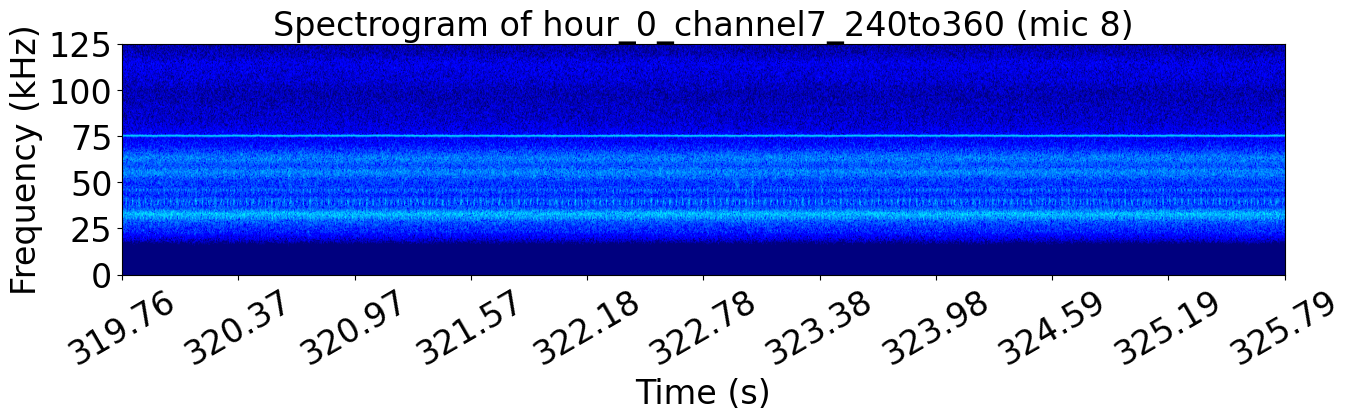

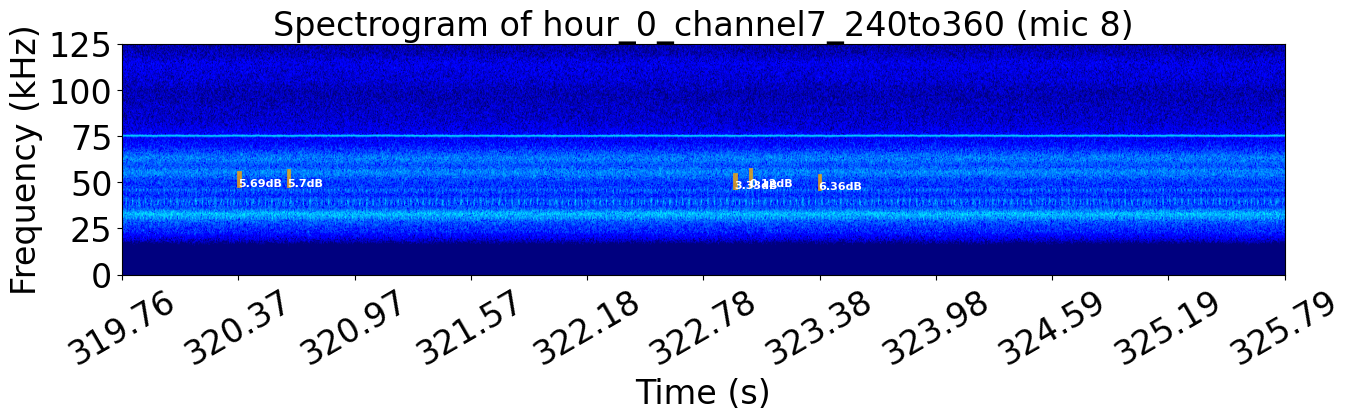

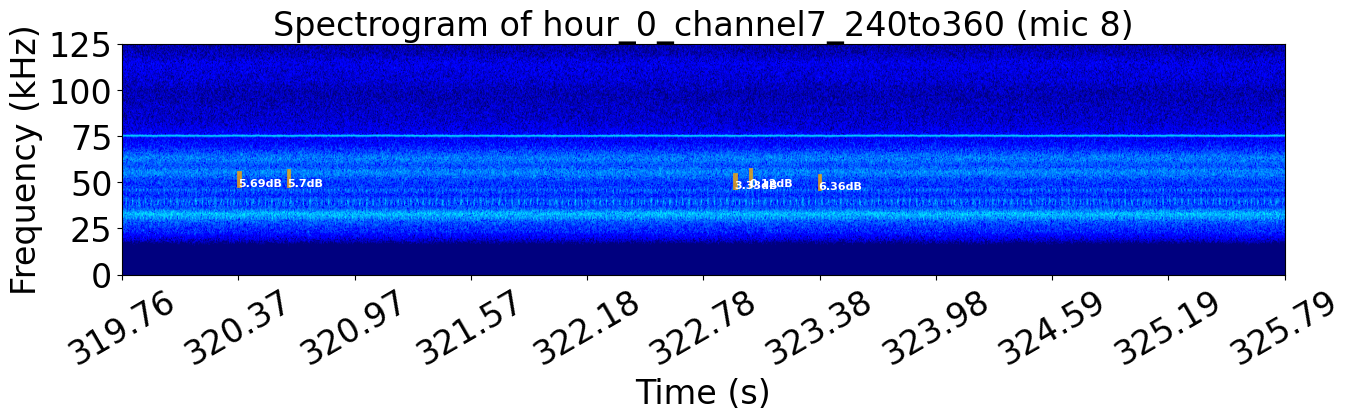

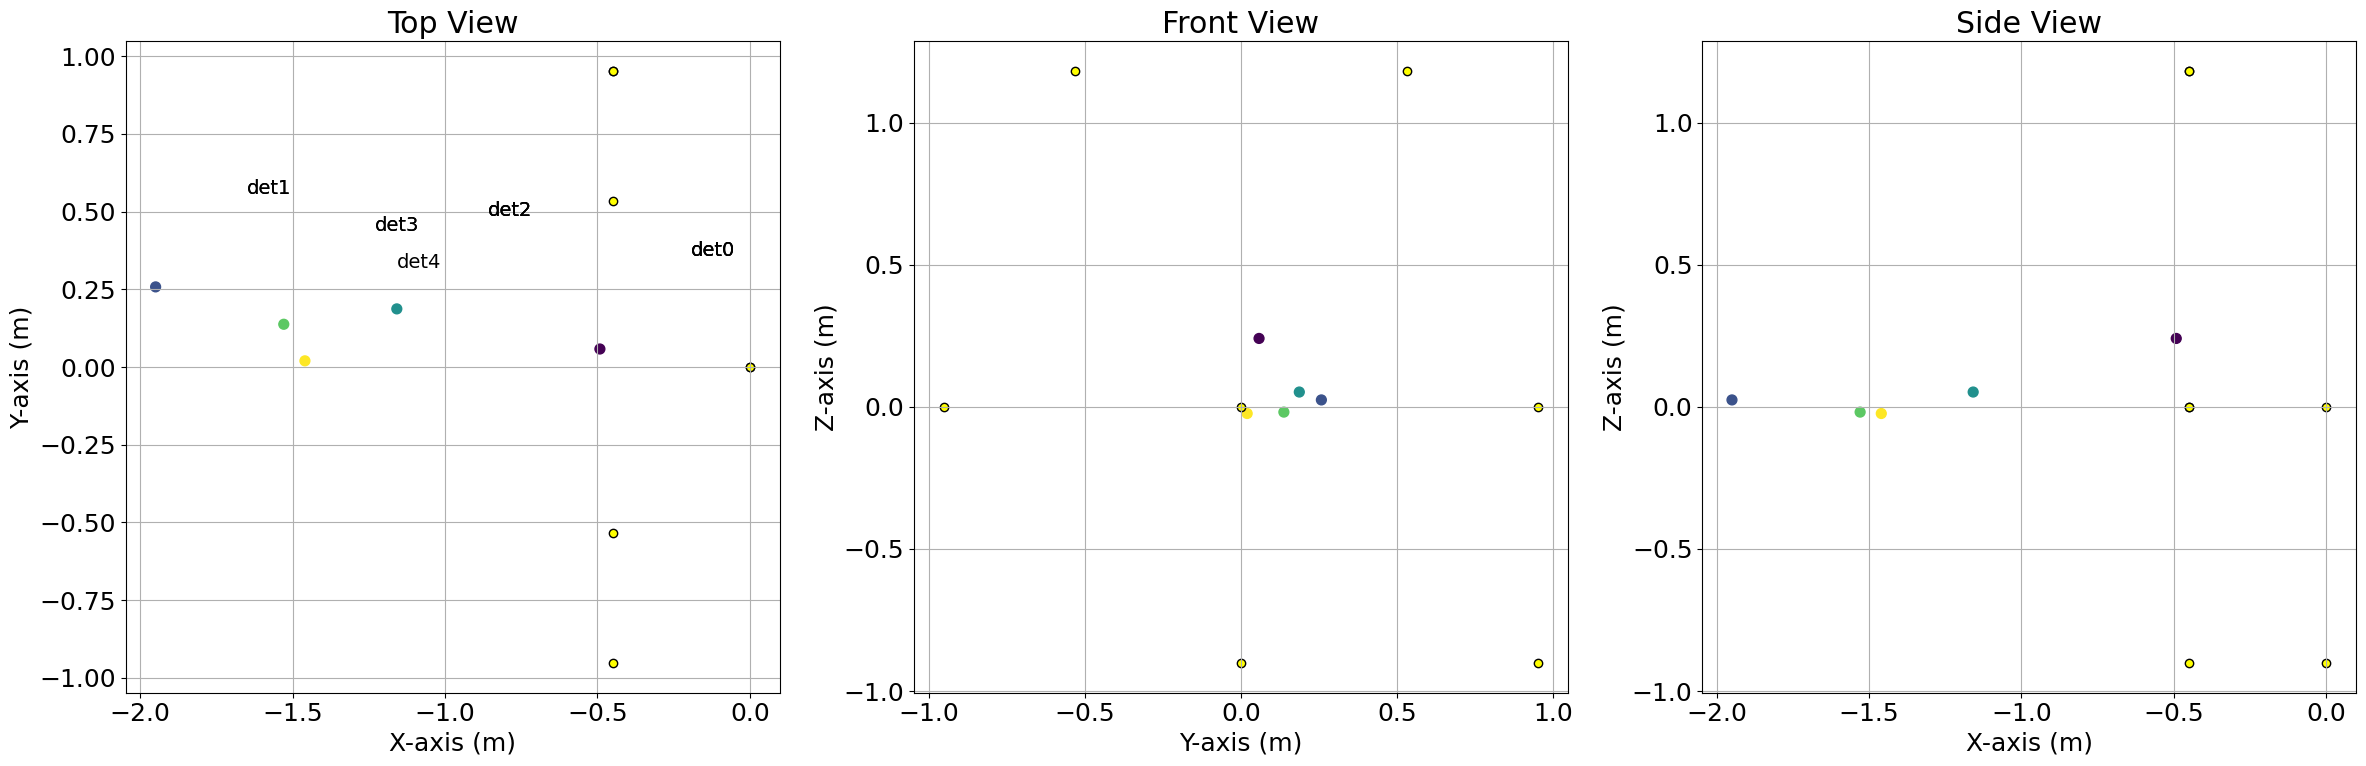

Currently at /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel7_240to360.WAV


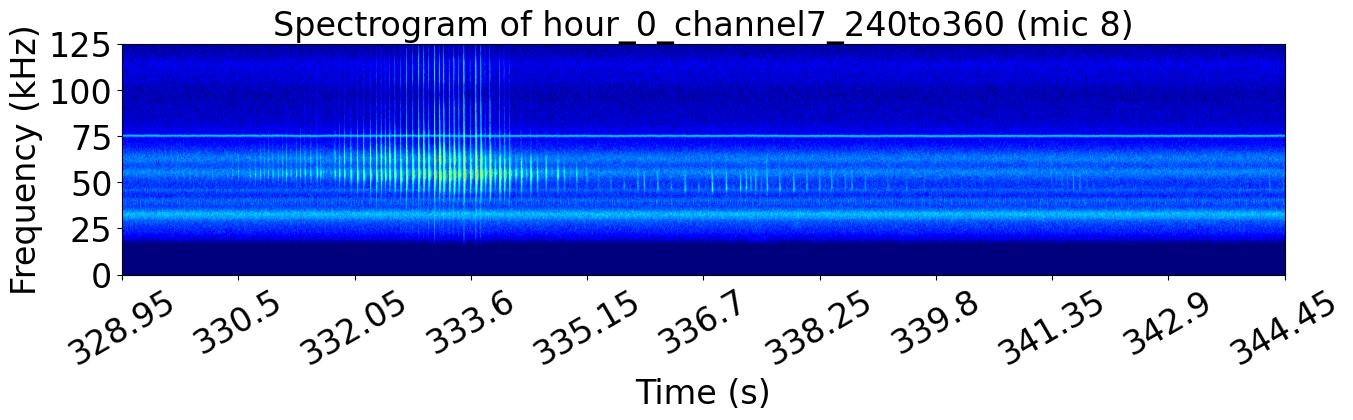

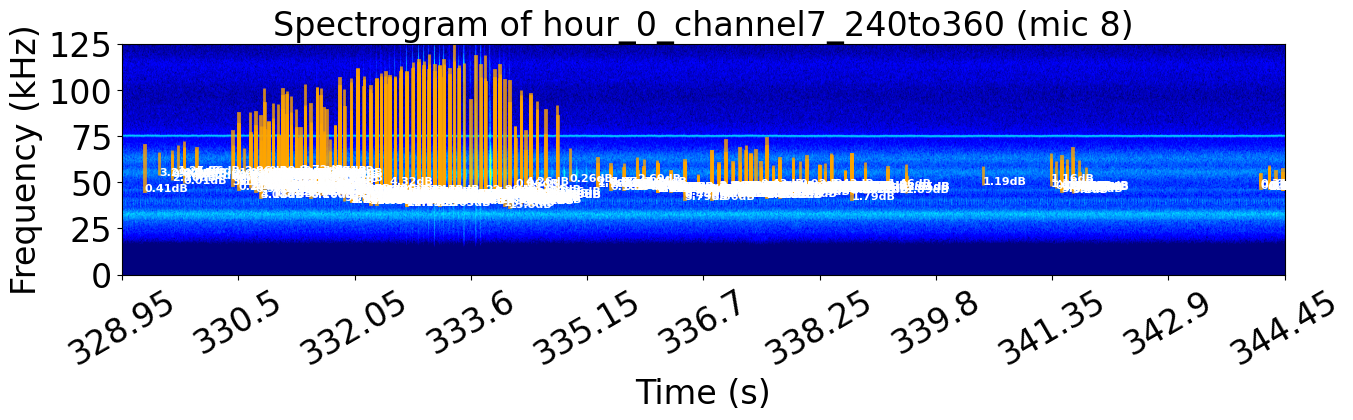

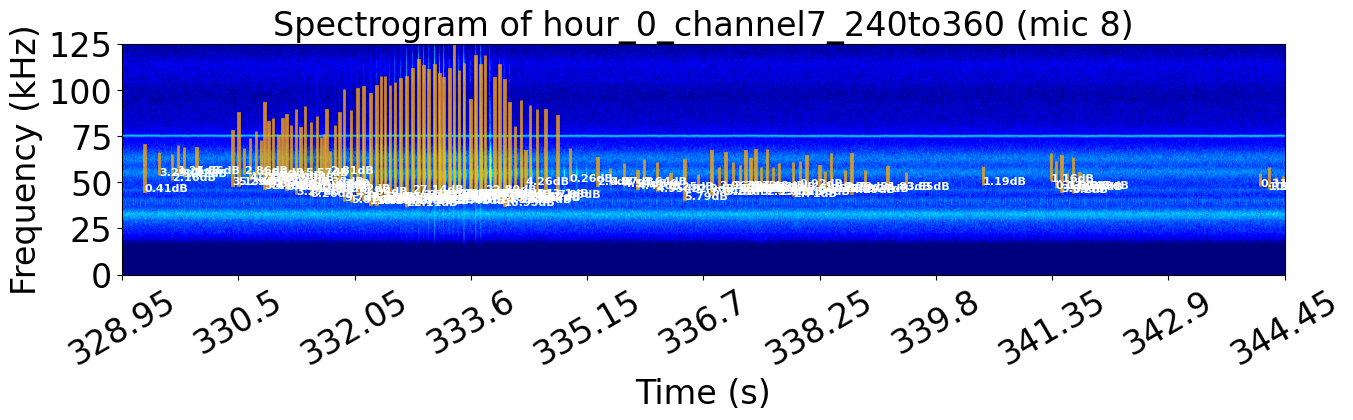

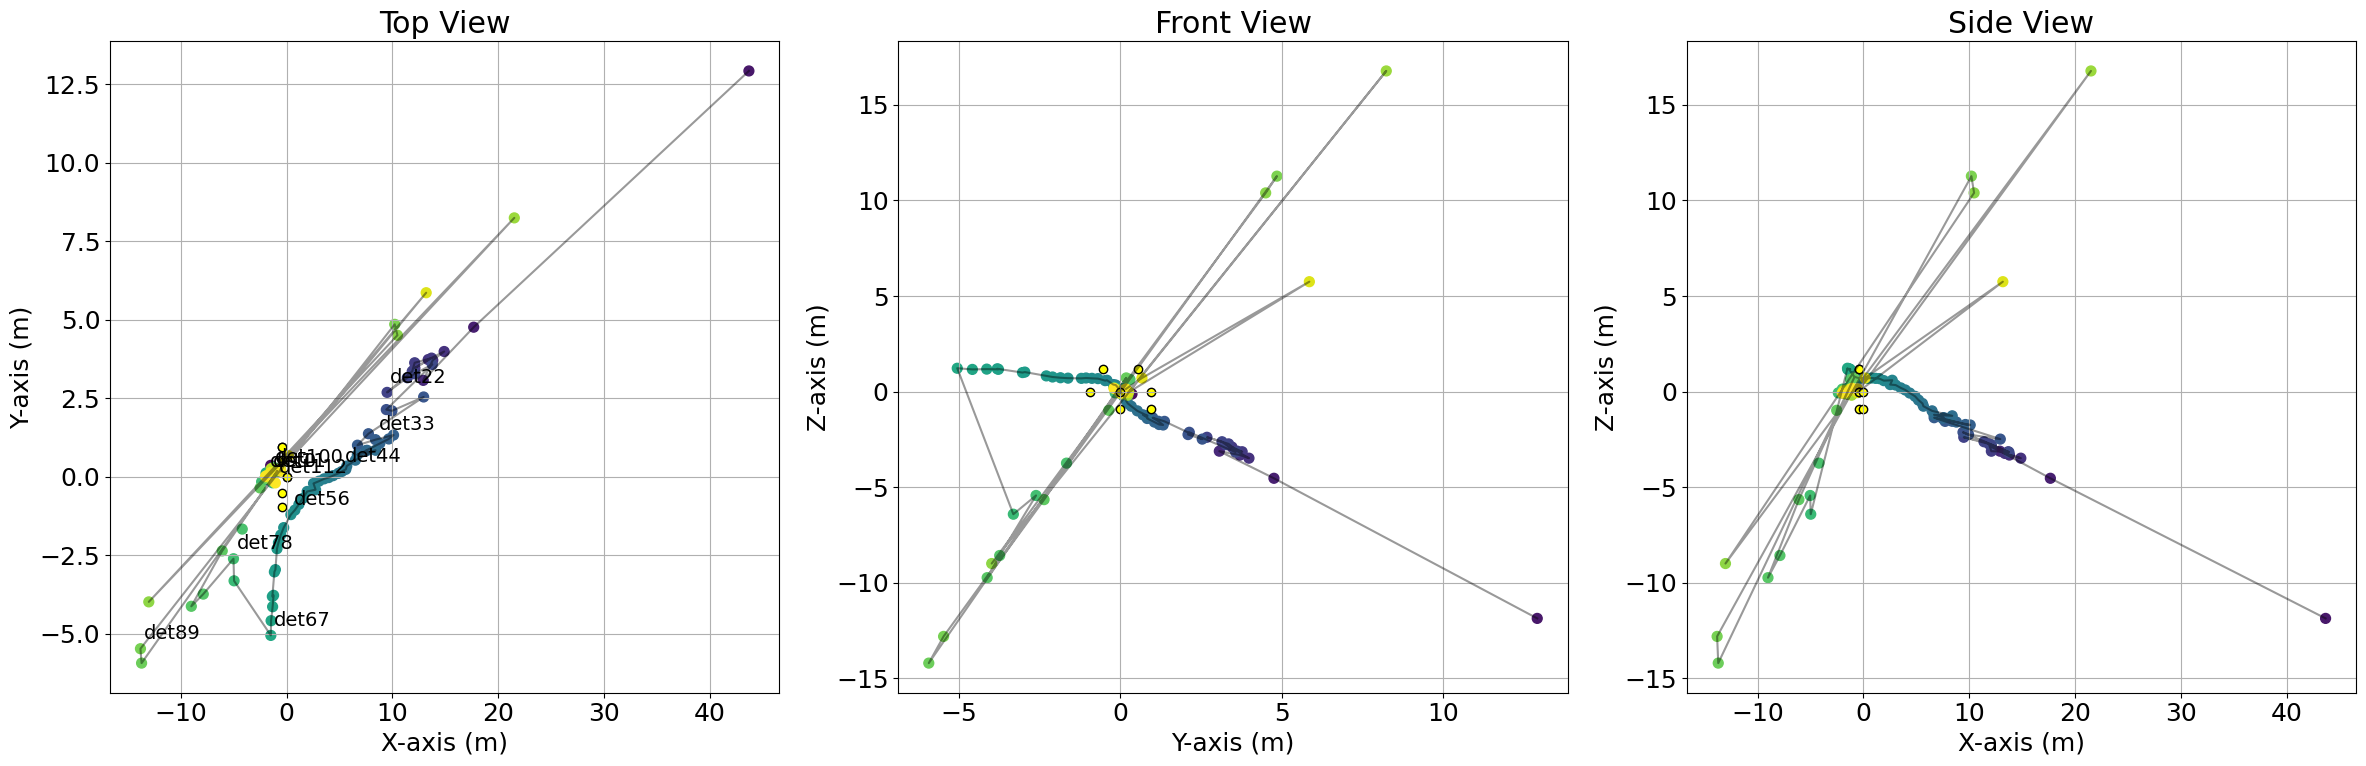

Currently at /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel7_240to360.WAV


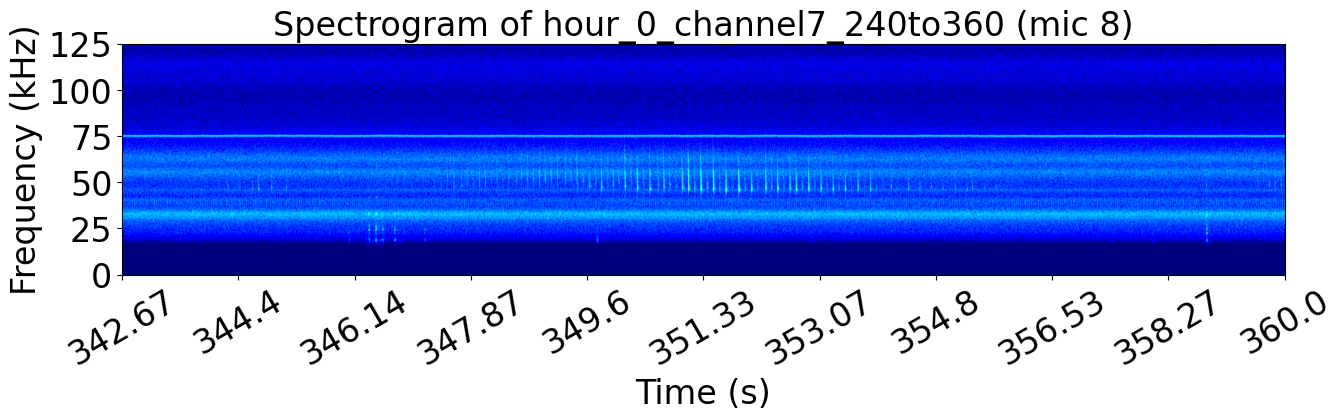

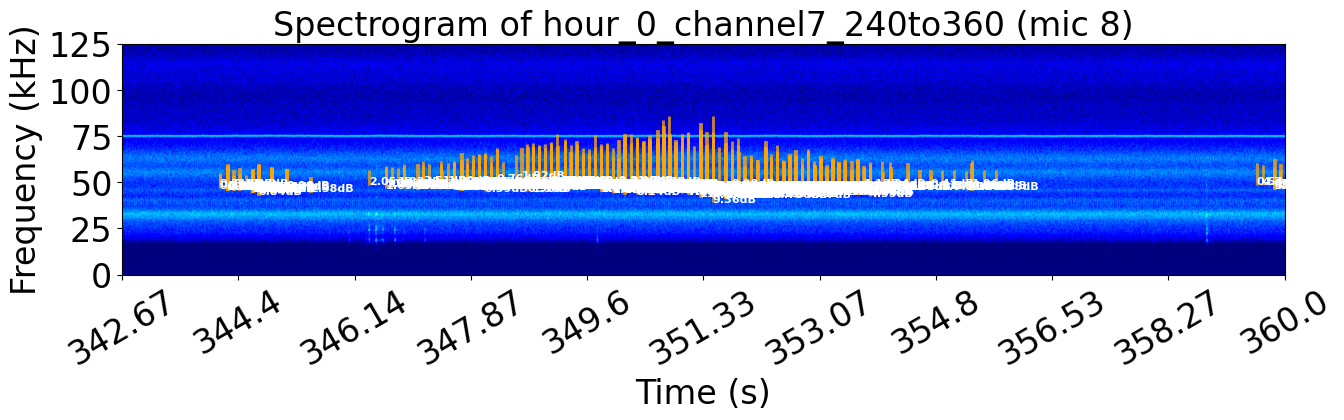

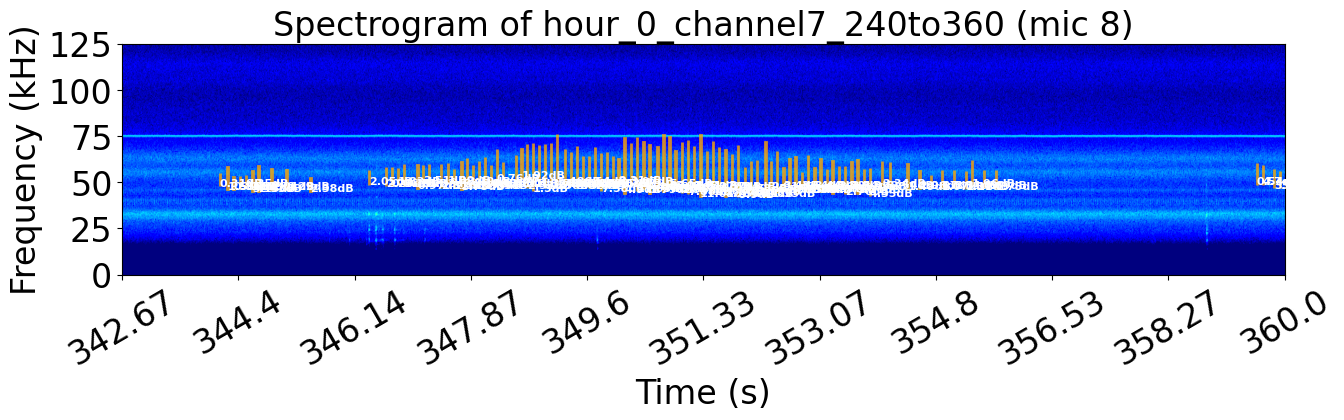

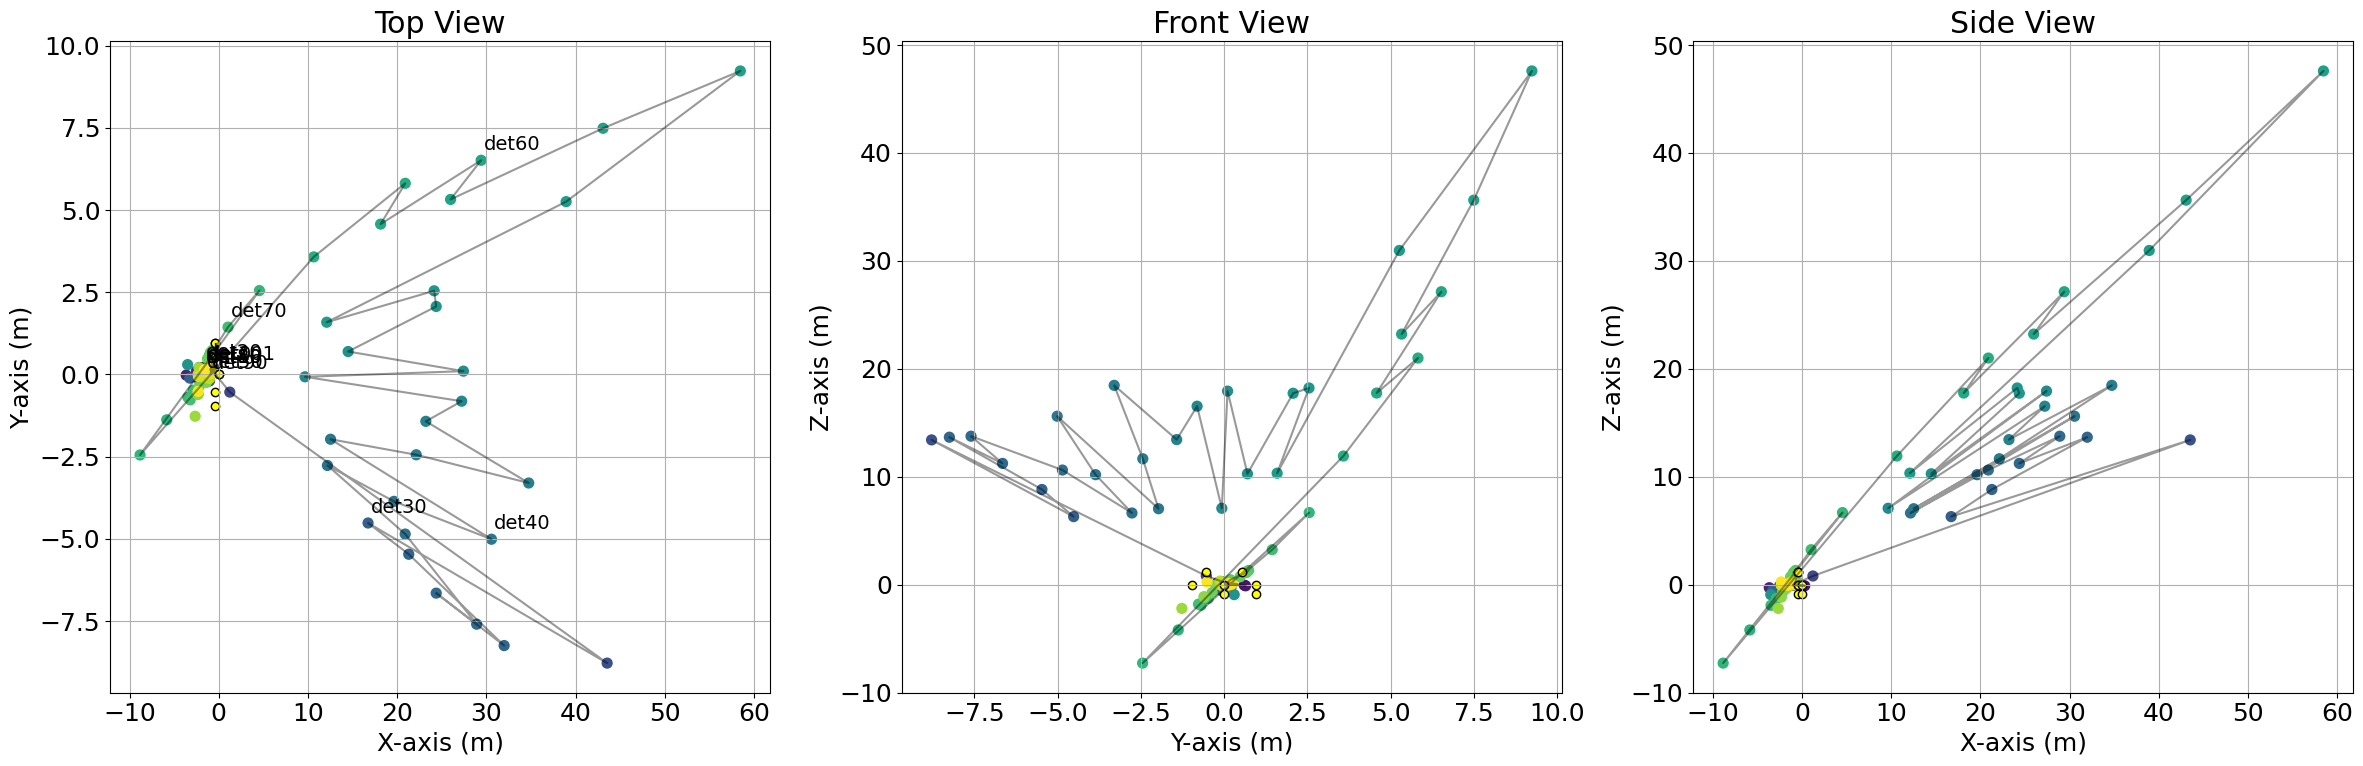

In [28]:
%matplotlib inline

# for file_offset in np.arange(0, 3600, 120):
file_offset = 240
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)

# if len(channel_dets)>0:
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
removed_overlaps = remove_overlapping_events(channel_dets, time_threshold=0.01)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=5].copy()
# if len(snr_thresh_dets)>0:
tagged_dets = clstr.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = clstr.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

for boutnum, bout in bout_metrics.iterrows():
    start = bout['start_time'] - file_offset - 0.2*bout['bout_duration_in_secs']
    length = min(bout['bout_duration_in_secs']*2, (FILE_DURATION) - start)
    plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
    plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

    if len(plot_dets[plot_dets['SNR']>=0])>0:
        set_for_tdoa = plot_dets[plot_dets['SNR']>=0].reset_index(drop=True).copy()
        # set_for_tdoa = set_for_tdoa[set_for_tdoa['start_time']<=331.6]
        plot_audio_bout(write_file, start, length, file_offset, plot_channel_dets, set_for_tdoa)

        calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
        t_delay_wrt_selected_channel = find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
        d_mics_to_ref, A_locs_mat_wrt_ref_channel_only_mics_used = get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel)

        bucket = assemble_source_points_in_meters(d_mics_to_ref, microphones_used, A_locs_mat_wrt_ref_channel_only_mics_used)
        bad_indices = ((bucket[0,:]<-1.0)&((np.abs(bucket[1,:])<2)|(np.abs(bucket[2,:])<0.8)))
        good_indices = ~bad_indices
        cleaned_bucket = bucket[:,good_indices]

        plt.figure(figsize=(24, 8))
        plt.rcParams.update({'font.size':18})
        plot_three_plane_trajectories(set_for_tdoa, cleaned_bucket, bucket, A_locs_mat_wrt_ref_channel_only_mics_used,
                                    start, length)
        plt.subplot(131)
        plt.title('Top View')
        plt.grid(which='both')
        plot_snr_and_mic_labels(bucket[0,:], bucket[1,:])
        plt.xlabel('X-axis (m)')
        plt.ylabel('Y-axis (m)')

        plt.subplot(132)
        plt.title('Front View')
        plt.grid(which='both')
        plt.xlabel('Y-axis (m)')
        plt.ylabel('Z-axis (m)')

        plt.subplot(133)
        plt.title('Side View')
        plt.grid(which='both')
        plt.xlabel('X-axis (m)')
        plt.ylabel('Z-axis (m)')

        plt.tight_layout()
        plt.show()

In [29]:
def convertVtoRL(observed_voltage_rms, sens_dB, mic_gain_dB_at_f, preamp_gain):
    preamp_gain_dB = 20*np.log10(preamp_gain)
    receive_voltage_dB = 20*np.log10(observed_voltage_rms) -  preamp_gain_dB
    RL_dB_with_mic_sensitivity = receive_voltage_dB - mic_gain_dB_at_f
    RL_dB_re_20uPa = RL_dB_with_mic_sensitivity - sens_dB - 20*np.log10(20e-6)

    return RL_dB_re_20uPa

def absorption(f, t=20, rh=60):
    """ In dB/m
    
        f: frequency in Hz
        t: temperature in °C
        rh: relative humidity in %
        ps: atmospheric pressure in Pa

        From http://en.wikibooks.org/wiki/Engineering_Acoustics/Outdoor_Sound_Propagation
        See __main__ for actual curves.
    """
    ## 1 atm in Pa
    ps0 = 1.01325e5
    ps = ps0

    if type(f) != int:
        f = f.reshape(1, len(f))
    if type(t) != int:
        t = t.reshape(len(t), 1)
    if type(rh) != int:
        rh = rh.reshape(len(rh), 1)
    T = t + 273.15
    T0 = 293.15
    T01 = 273.16

    Csat = -6.8346 * np.power(T01 / T, 1.261) + 4.6151
    rhosat = np.power(10, Csat)
    H = rhosat * rh * ps0 / ps

    frn = (ps / ps0) * np.power(T0 / T, 0.5) * (
            9 + 280 * H * np.exp(-4.17 * (np.power(T0 / T, 1/3.) - 1)))

    fro = (ps / ps0) * (24.0 + 4.04e4 * H * (0.02 + H) / (0.391 + H))

    alpha = f * f * (
        1.84e-11 / ( np.power(T0 / T, 0.5) * ps / ps0 )
        + np.power(T / T0, -2.5)
        * (
            0.10680 * np.exp(-3352 / T) * frn / (f * f + frn * frn)
            + 0.01278 * np.exp(-2239.1 / T) * fro / (f * f + fro * fro)
            )
        )

    return 20 * alpha / np.log(10)

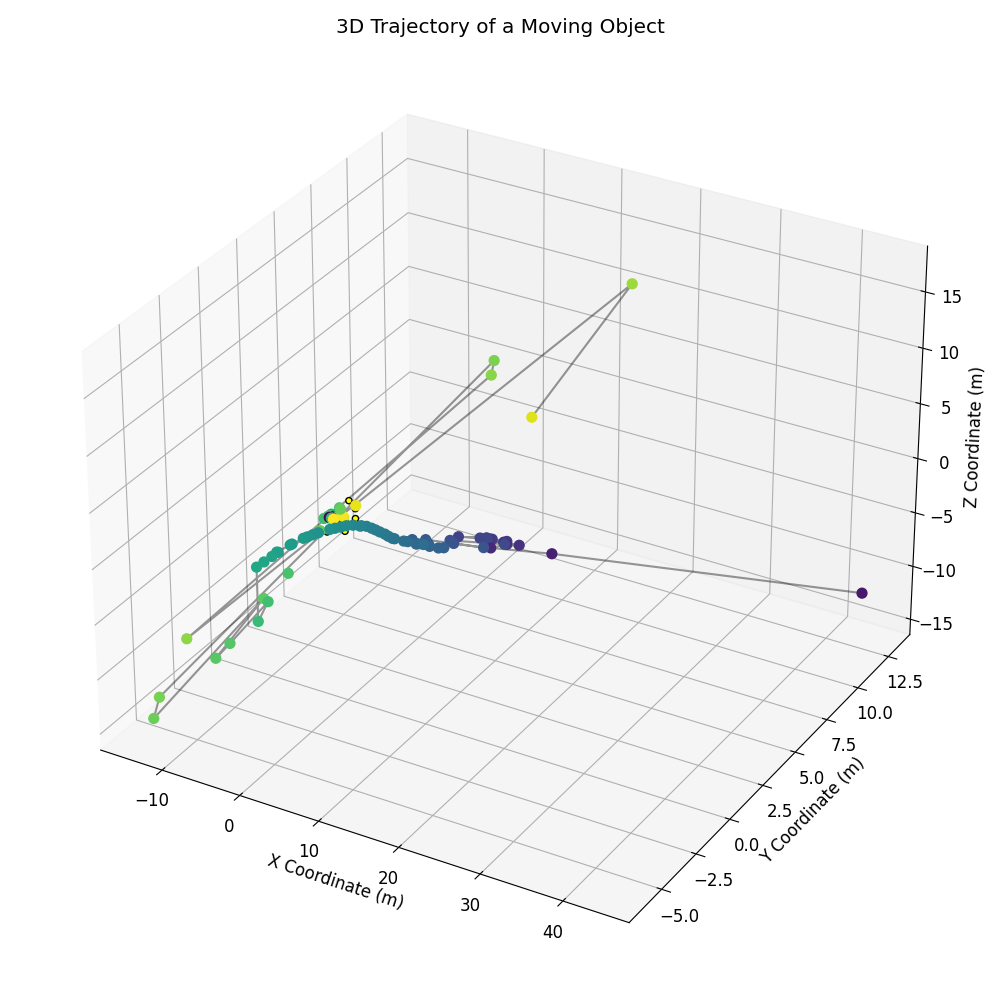

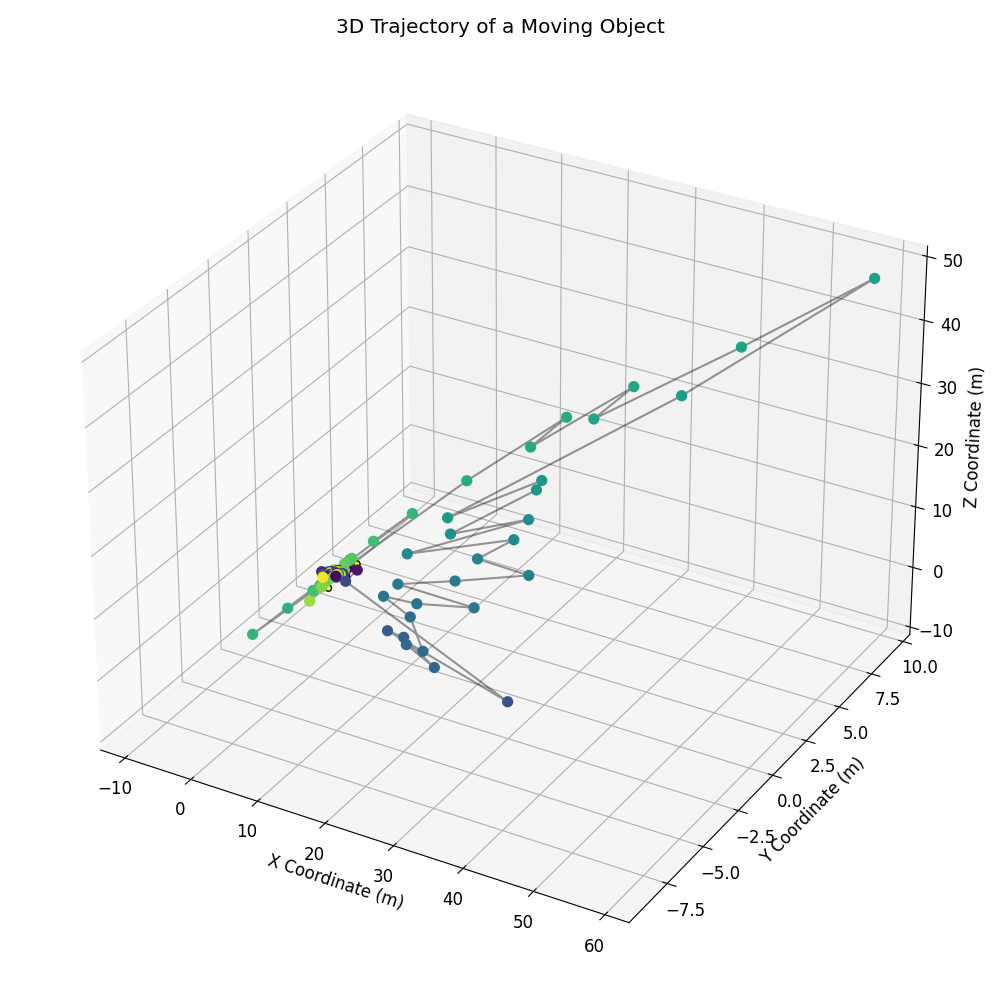

In [32]:
%matplotlib widget

# for file_offset in np.arange(0, 3600, 120):
file_offset = 240
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)

# if len(channel_dets)>0:
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
removed_overlaps = remove_overlapping_events(channel_dets, time_threshold=0.01)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=5].copy()
# if len(snr_thresh_dets)>0:
tagged_dets = clstr.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = clstr.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

for boutnum, bout in bout_metrics.iterrows():
    start = bout['start_time'] - file_offset - 0.2*bout['bout_duration_in_secs']
    length = min(bout['bout_duration_in_secs']*2, (FILE_DURATION) - start)
    plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
    plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

    if len(plot_dets[plot_dets['SNR']>=0])>0:
        set_for_tdoa = plot_dets[plot_dets['SNR']>=0].reset_index(drop=True).copy()
        # set_for_tdoa = set_for_tdoa[set_for_tdoa['start_time']<=331.6]

        calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
        t_delay_wrt_selected_channel = find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
        d_mics_to_ref, A_locs_mat_wrt_ref_channel_only_mics_used = get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel)

        bucket = assemble_source_points_in_meters(d_mics_to_ref, microphones_used, A_locs_mat_wrt_ref_channel_only_mics_used)
        bad_indices = (bucket[0,:]<0.2)&((np.abs(bucket[1,:])<2)|(np.abs(bucket[2,:])<0.8))
        good_indices = ~bad_indices
        cleaned_bucket = bucket[:,good_indices]
        if (cleaned_bucket.shape[1])>1:
            good_dets = set_for_tdoa[good_indices]

            a = 0.003
            wavelength = C / good_dets['peak_frequency'].values
            k = 2*np.pi/wavelength
            ka = k*a
            theta = np.pi/2

            dist_bat_from_ref_mic = (np.sum(cleaned_bucket[:3,:]**2, axis=0))**0.5
            call_vrms_vals = call_voltage_rms[good_indices, ind_of_selected_channel]
            RL_dB_re_20uPa = convertVtoRL(call_vrms_vals, -38, 12, 200)
            ### Atmospheric attenuation found usinh Jakobsen at. al 2013
            atmos_loss_DB = absorption(good_dets['peak_frequency'].values)*dist_bat_from_ref_mic
            ### Geometric Spreading calculated using Jakobsen et. al 2013
            spreading_dB = 20*np.log10(dist_bat_from_ref_mic)
            D_theta = 2*special.j1(ka*np.sin(theta))/(ka*np.sin(theta))
            D_theta_dB = -20*np.log10(np.abs(D_theta))
            TL_dB = atmos_loss_DB+spreading_dB+D_theta_dB
            bat_SL_dB_re_20uPa = RL_dB_re_20uPa + TL_dB

            delta_t = good_dets['start_time'][1:].reset_index(drop=True) - good_dets['end_time'][:-1].reset_index(drop=True)
            delta_x = (cleaned_bucket[0,1:] - cleaned_bucket[0,:-1])
            delta_y = (cleaned_bucket[1,1:] - cleaned_bucket[1,:-1])
            delta_z = (cleaned_bucket[2,1:] - cleaned_bucket[2,:-1])
            delta_dist = ((delta_x**2) + (delta_y**2) + (delta_z**2))**0.5

            flight_speed_per_2points = (delta_dist/delta_t.values)

            fig = plt.figure(figsize=(10, 10))
            plt.rcParams.update({'font.size':12})
            ax = fig.add_subplot(projection='3d')

            cmap = plt.get_cmap('viridis')
            map_vals = (set_for_tdoa['SNR'])
            color_vals = np.linspace(start, start+length, bucket.shape[1])
            norm = plt.Normalize(color_vals.min(), color_vals.max())
            line_colors = cmap(norm(color_vals))
            
            ax.scatter(bucket[0,:], bucket[1,:], bucket[2,:], color=line_colors, alpha=1, s=50)
            ax.plot(cleaned_bucket[0,:], cleaned_bucket[1,:], cleaned_bucket[2,:], color='k', alpha=0.4)
            
            ax.scatter(xs=A_locs_mat_wrt_ref_channel_only_mics_used[:,0] * (254/10000), 
                    ys=A_locs_mat_wrt_ref_channel_only_mics_used[:,1] * (254/10000), 
                    zs=A_locs_mat_wrt_ref_channel_only_mics_used[:,2] * (254/10000), facecolor='yellow', edgecolor='k', alpha=1)
            ax.scatter(xs=0, ys=0, zs=0, facecolor='yellow', edgecolor='k', alpha=1)

            ax.set_xlabel('X Coordinate (m)')
            ax.set_ylabel('Y Coordinate (m)')
            ax.set_zlabel('Z Coordinate (m)')
            ax.set_title('3D Trajectory of a Moving Object')

            plt.tight_layout()
            plt.show()